# 02 — E-Waste Classification using ResNet18
**Project:** E-Waste Component Classification | SDG 12.4  
**Technique:** Deep Neural Network (CNN) — Transfer Learning  
**Dataset:** MASTER_DATASET (20 classes, ~12,706 images)

## Cell 1 — Install Dependencies

In [1]:
# Run once
%pip install torch torchvision matplotlib scikit-learn seaborn tqdm
print("All libraries should already be installed from requirements.txt")

Note: you may need to restart the kernel to use updated packages.
All libraries should already be installed from requirements.txt


## Cell 2 — Imports

In [2]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, accuracy_score)
from tqdm import tqdm

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version : {torch.__version__}")
print(f"Device          : CPU (no GPU detected — using CPU training)")
device = torch.device("cpu")

PyTorch version : 2.11.0+cpu
Device          : CPU (no GPU detected — using CPU training)


## Cell 3 — Configuration

In [3]:
# ── UPDATE THIS PATH TO YOUR MASTER_DATASET ──────────────────────
DATA_DIR    = r"D:\Downloads\MASTER_DATASET"
MODEL_DIR   = r"D:\Github Desktop\ewaste_vit_project\models\cnn_resnet18"
os.makedirs(MODEL_DIR, exist_ok=True)

# ── Hyperparameters (CPU-optimised) ──────────────────────────────
IMG_SIZE    = 224
BATCH_SIZE  = 16       # small batch for CPU
NUM_EPOCHS  = 15       # enough for transfer learning on CPU
LR          = 1e-4
NUM_CLASSES = 20
NUM_WORKERS = 0        # always 0 on Windows CPU

print(f"Data directory  : {DATA_DIR}")
print(f"Model directory : {MODEL_DIR}")
print(f"Image size      : {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch size      : {BATCH_SIZE}")
print(f"Epochs          : {NUM_EPOCHS}")

Data directory  : D:\Downloads\MASTER_DATASET
Model directory : D:\Github Desktop\ewaste_vit_project\models\cnn_resnet18
Image size      : 224x224
Batch size      : 16
Epochs          : 15


## Cell 4 — Data Transforms & Loaders

In [4]:
# ImageNet mean/std for pretrained ResNet18
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

# Load datasets
train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=train_transform)
val_dataset   = datasets.ImageFolder(os.path.join(DATA_DIR, "val"),   transform=val_test_transform)
test_dataset  = datasets.ImageFolder(os.path.join(DATA_DIR, "test"),  transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Class names
CLASS_NAMES = train_dataset.classes
print(f"Classes ({len(CLASS_NAMES)}): {CLASS_NAMES}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Classes (20): ['Battery', 'Capacitor', 'Integrated-micro-circuit', 'Keyboard', 'LED', 'Microwave', 'Mobile', 'Mouse', 'PCB', 'Player', 'Printer', 'Resistor', 'Television', 'Washing Machine', 'heat-sink', 'light bulbs', 'microchip', 'microprocessor', 'semiconductor-diode', 'transistor']
Train: 9679 | Val: 1552 | Test: 1475


## Cell 5 — Model Setup (ResNet18 Transfer Learning)

In [5]:
def build_resnet18(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # Freeze all backbone layers
    for param in model.parameters():
        param.requires_grad = False

    # Replace final classification layer
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes)
    )
    return model

model = build_resnet18(NUM_CLASSES).to(device)

# Count trainable parameters
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters : {trainable:,}")
print(f"Total parameters     : {total:,}")
print(f"Frozen parameters    : {total - trainable:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\harsh/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:07<00:00, 6.42MB/s]


Trainable parameters : 136,468
Total parameters     : 11,312,980
Frozen parameters    : 11,176,512


## Cell 6 — Loss, Optimizer & Scheduler

In [6]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

print(f"Loss      : CrossEntropyLoss (label smoothing=0.1)")
print(f"Optimizer : Adam (lr={LR}, weight_decay=1e-4)")
print(f"Scheduler : StepLR (step=5, gamma=0.5)")

Loss      : CrossEntropyLoss (label smoothing=0.1)
Optimizer : Adam (lr=0.0001, weight_decay=1e-4)
Scheduler : StepLR (step=5, gamma=0.5)


## Cell 7 — Training & Validation Loop

In [7]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, desc="Train", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct  += (preds == labels).sum().item()
        total    += labels.size(0)
    return running_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Eval ", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct  += (preds == labels).sum().item()
            total    += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return running_loss / total, correct / total, all_preds, all_labels


# ── Training loop ────────────────────────────────────────────────
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc  = 0.0
best_model_path = os.path.join(MODEL_DIR, "resnet18_best.pth")

print(f"Starting training — {NUM_EPOCHS} epochs on CPU")
print("This may take 2–4 hours on CPU. Grab a coffee!")
print("-" * 60)

for epoch in range(1, NUM_EPOCHS + 1):
    start = time.time()

    # Phase 1: train head only (epochs 1–5)
    # Phase 2: unfreeze layer4 + fc (epochs 6+)
    if epoch == 6:
        for name, param in model.named_parameters():
            if "layer4" in name or "fc" in name:
                param.requires_grad = True
        optimizer = optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=LR * 0.1, weight_decay=1e-4
        )
        print("  >> Unfroze layer4 + fc for fine-tuning")

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss,   val_acc, _, _ = evaluate(model, val_loader, criterion)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    elapsed = time.time() - start
    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
          f"Time: {elapsed:.1f}s")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"  >> Best model saved (val_acc={best_val_acc:.4f})")

print(f"\nTraining complete. Best val accuracy: {best_val_acc:.4f}")

Starting training — 15 epochs on CPU
This may take 2–4 hours on CPU. Grab a coffee!
------------------------------------------------------------


Train:  20%|█▉        | 119/605 [01:36<06:28,  1.25it/s]d:\Github Desktop\ewaste_vit_project\.venv\Lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 01/15 | Train Loss: 2.5563 Acc: 0.2876 | Val Loss: 1.9643 Acc: 0.5825 | Time: 758.0s
  >> Best model saved (val_acc=0.5825)


Epoch 02/15 | Train Loss: 2.0415 Acc: 0.4883 | Val Loss: 1.6791 Acc: 0.6082 | Time: 665.7s
  >> Best model saved (val_acc=0.6082)


Epoch 03/15 | Train Loss: 1.8420 Acc: 0.5506 | Val Loss: 1.6030 Acc: 0.6424 | Time: 384.5s
  >> Best model saved (val_acc=0.6424)


...

Epoch 11/15 | Train Loss: 1.2406 Acc: 0.7737 | Val Loss: 1.2327 Acc: 0.7745 | Time: 506.8s
  >> Best model saved (val_acc=0.7745)


Epoch 12/15 | Train Loss: 1.2089 Acc: 0.7837 | Val Loss: 1.2108 Acc: 0.7809 | Time: 507.2s
  >> Best model saved (val_acc=0.7809)


Epoch 13/15 | Train Loss: 1.1746 Acc: 0.7989 | Val Loss: 1.2052 Acc: 0.7835 | Time: 770.4s
  >> Best model saved (val_acc=0.7835)


Epoch 14/15 | Train Loss: 1.1572 Acc: 0.8068 | Val Loss: 1.1960 Acc: 0.7816 | Time: 506.8s


Epoch 15/15 | Train Loss: 1.1333 Acc: 0.8147 | Val Loss: 1.1804 Acc: 0.7945 | Time: 502.8s
  >> Best model saved (val_acc=0.7945)

Training complete. Best val accuracy: 0.7945


## Cell 8 — Plot Training Curves

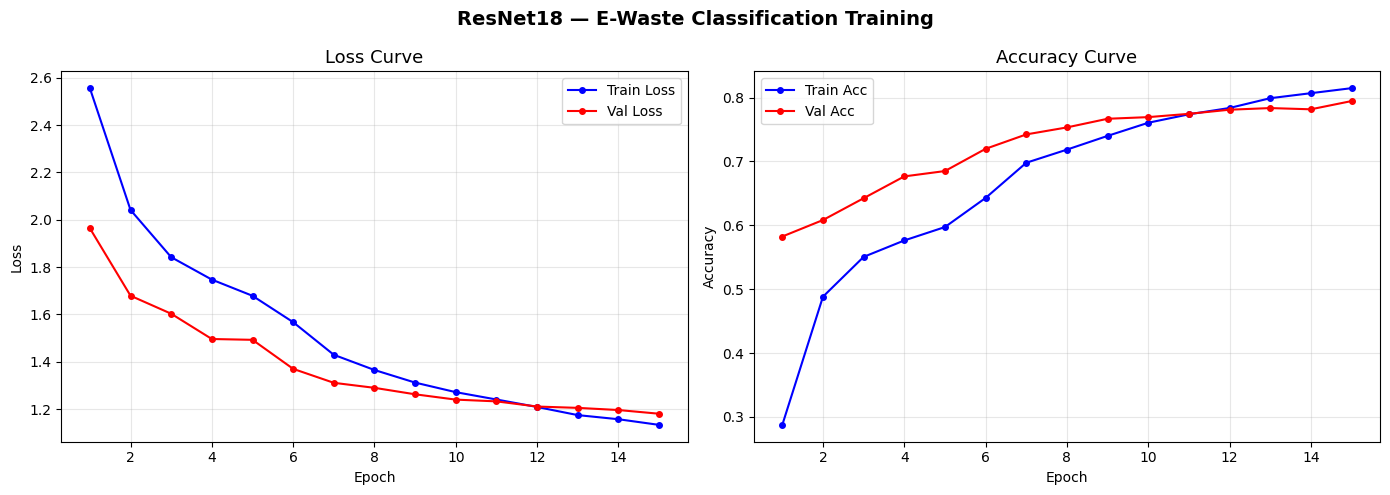

Training curves saved.


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history["train_loss"]) + 1)

ax1.plot(epochs, history["train_loss"], "b-o", label="Train Loss", markersize=4)
ax1.plot(epochs, history["val_loss"],   "r-o", label="Val Loss",   markersize=4)
ax1.set_title("Loss Curve", fontsize=13)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(epochs, history["train_acc"], "b-o", label="Train Acc", markersize=4)
ax2.plot(epochs, history["val_acc"],   "r-o", label="Val Acc",   markersize=4)
ax2.set_title("Accuracy Curve", fontsize=13)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle("ResNet18 — E-Waste Classification Training", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Training curves saved.")

## Cell 9 — Test Set Evaluation

In [9]:
# Load best model
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

test_loss, test_acc, all_preds, all_labels = evaluate(model, test_loader, criterion)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Macro F1      : {f1_score(all_labels, all_preds, average='macro'):.4f}")
print()
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4))

Test Loss     : 1.2031
Test Accuracy : 0.7851 (78.51%)
Macro F1      : 0.8003

                          precision    recall  f1-score   support

                 Battery     0.8659    0.9509    0.9064       163
               Capacitor     0.8193    0.7083    0.7598        96
Integrated-micro-circuit     0.5982    0.9125    0.7227       297
                Keyboard     1.0000    0.9667    0.9831        30
                     LED     0.8395    0.7816    0.8095        87
               Microwave     0.8571    1.0000    0.9231        30
                  Mobile     0.9677    1.0000    0.9836        30
                   Mouse     0.9062    0.9667    0.9355        30
                     PCB     0.7600    0.6333    0.6909        30
                  Player     0.8621    0.8333    0.8475        30
                 Printer     0.9630    0.8667    0.9123        30
                Resistor     0.9877    0.9195    0.9524        87
              Television     1.0000    0.9000    0.9474       

## Cell 10 — Confusion Matrix

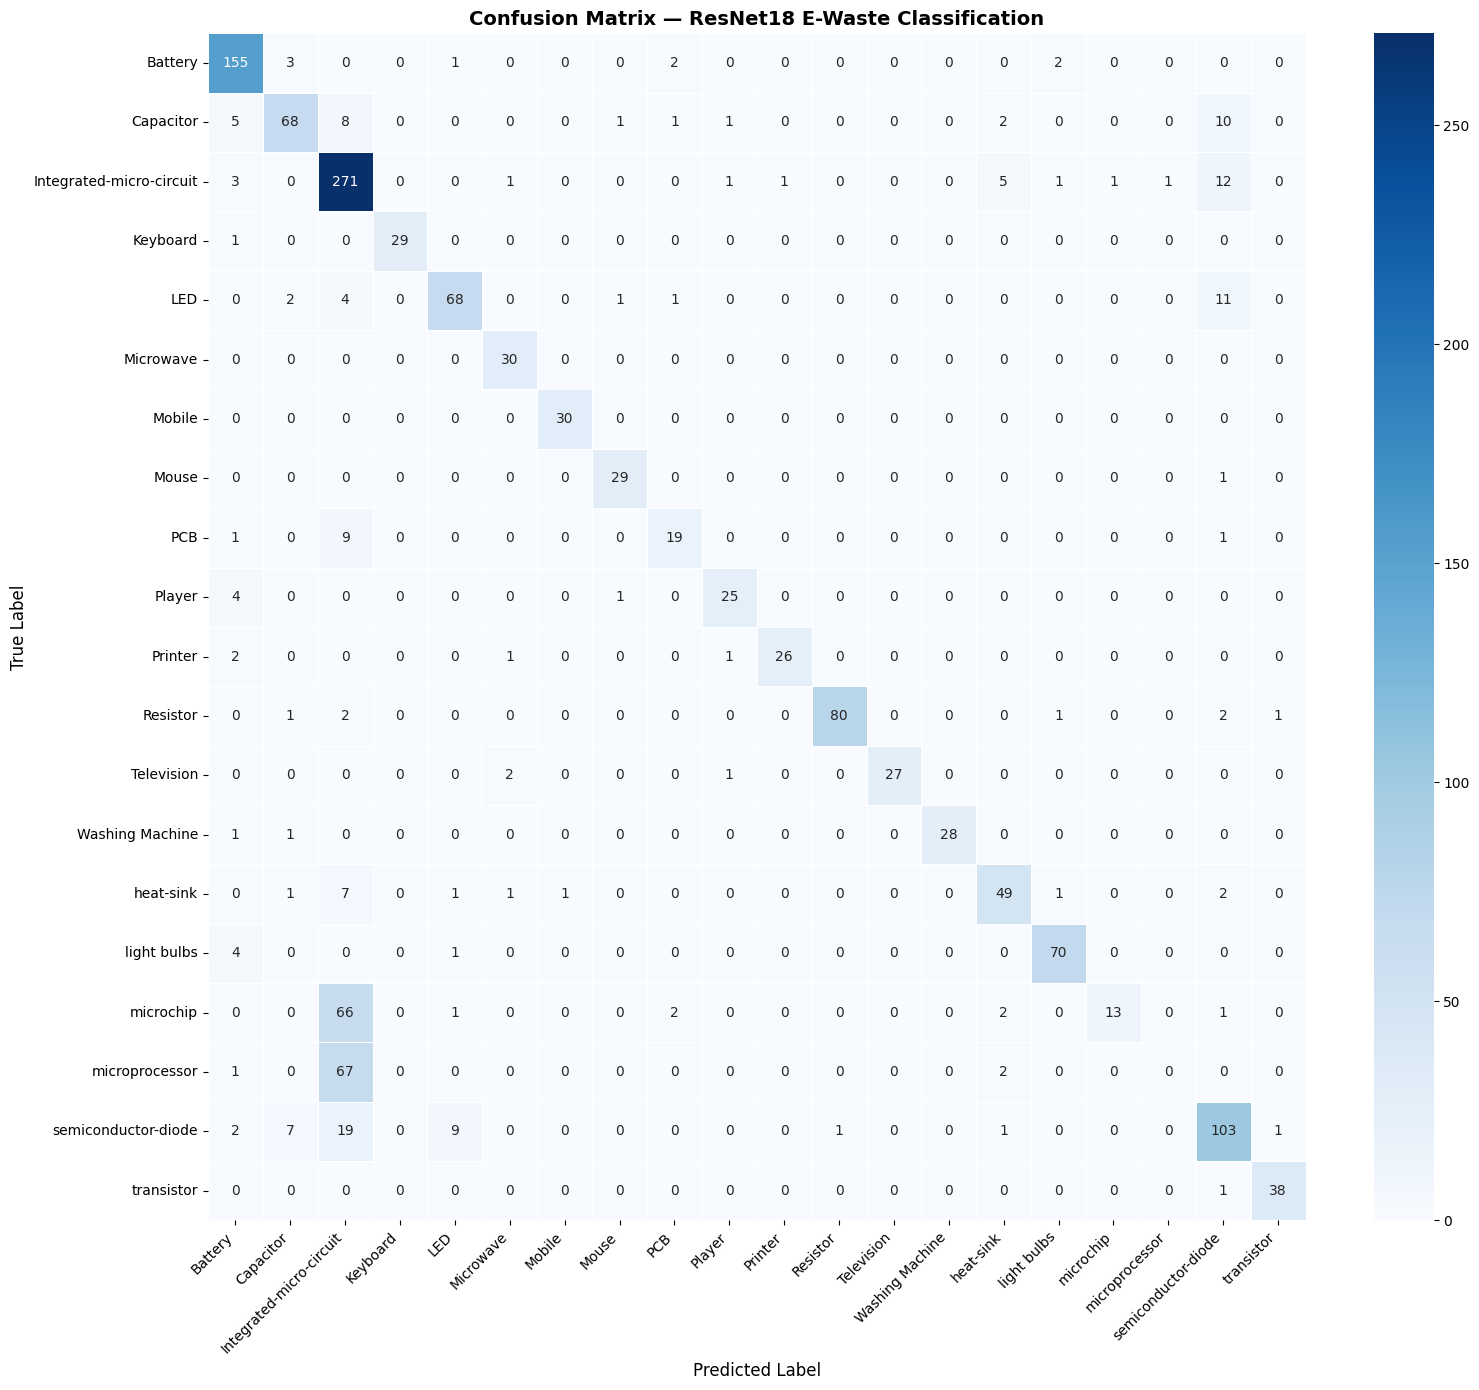

Confusion matrix saved.


In [10]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            linewidths=0.5)
plt.title("Confusion Matrix — ResNet18 E-Waste Classification", fontsize=14, fontweight="bold")
plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Confusion matrix saved.")

## Cell 11 — Per-Class F1 Bar Chart

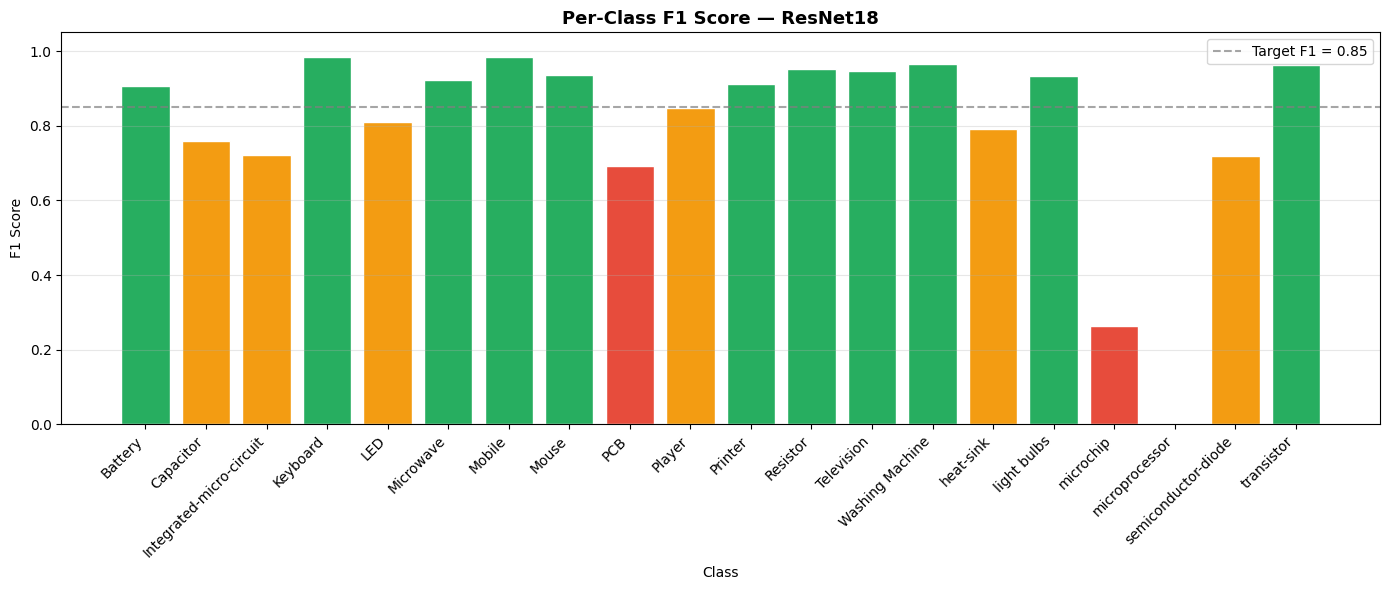

  Battery                             F1: 0.9064 
  Capacitor                           F1: 0.7598 
  Integrated-micro-circuit            F1: 0.7227 
  Keyboard                            F1: 0.9831 
  LED                                 F1: 0.8095 
  Microwave                           F1: 0.9231 
  Mobile                              F1: 0.9836 
  Mouse                               F1: 0.9355 
  PCB                                 F1: 0.6909 ⚠️
  Player                              F1: 0.8475 
  Printer                             F1: 0.9123 
  Resistor                            F1: 0.9524 
  Television                          F1: 0.9474 
  Washing Machine                     F1: 0.9655 
  heat-sink                           F1: 0.7903 
  light bulbs                         F1: 0.9333 
  microchip                           F1: 0.2626 ⚠️
  microprocessor                      F1: 0.0000 ⚠️
  semiconductor-diode                 F1: 0.7178 
  transistor                          F1: 0.

In [11]:
from sklearn.metrics import f1_score

per_class_f1 = f1_score(all_labels, all_preds, average=None)

plt.figure(figsize=(14, 6))
colors = ["#e74c3c" if f < 0.7 else "#f39c12" if f < 0.85 else "#27ae60"
          for f in per_class_f1]
bars = plt.bar(CLASS_NAMES, per_class_f1, color=colors, edgecolor="white")
plt.axhline(y=0.85, color="gray", linestyle="--", alpha=0.7, label="Target F1 = 0.85")
plt.title("Per-Class F1 Score — ResNet18", fontsize=13, fontweight="bold")
plt.xlabel("Class")
plt.ylabel("F1 Score")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "per_class_f1.png"), dpi=150, bbox_inches="tight")
plt.show()

for cls, f1 in zip(CLASS_NAMES, per_class_f1):
    flag = "⚠️" if f1 < 0.7 else ""
    print(f"  {cls:<35} F1: {f1:.4f} {flag}")

## Cell 12 — Save Results Summary

In [12]:
import json

results = {
    "model"        : "ResNet18",
    "test_accuracy": round(test_acc, 4),
    "test_loss"    : round(test_loss, 4),
    "macro_f1"     : round(f1_score(all_labels, all_preds, average="macro"), 4),
    "per_class_f1" : {cls: round(f1, 4) for cls, f1 in zip(CLASS_NAMES, per_class_f1)},
    "num_classes"  : NUM_CLASSES,
    "epochs"       : NUM_EPOCHS,
    "best_val_acc" : round(best_val_acc, 4),
}

results_path = os.path.join(MODEL_DIR, "results.json")
with open(results_path, "w") as f:
    json.dump(results, f, indent=2)

print(f"Results saved to {results_path}")
print(json.dumps(results, indent=2))

Results saved to D:\Github Desktop\ewaste_vit_project\models\cnn_resnet18\results.json
{
  "model": "ResNet18",
  "test_accuracy": 0.7851,
  "test_loss": 1.2031,
  "macro_f1": 0.8003,
  "per_class_f1": {
    "Battery": 0.9064,
    "Capacitor": 0.7598,
    "Integrated-micro-circuit": 0.7227,
    "Keyboard": 0.9831,
    "LED": 0.8095,
    "Microwave": 0.9231,
    "Mobile": 0.9836,
    "Mouse": 0.9355,
    "PCB": 0.6909,
    "Player": 0.8475,
    "Printer": 0.9123,
    "Resistor": 0.9524,
    "Television": 0.9474,
    "Washing Machine": 0.9655,
    "heat-sink": 0.7903,
    "light bulbs": 0.9333,
    "microchip": 0.2626,
    "microprocessor": 0.0,
    "semiconductor-diode": 0.7178,
    "transistor": 0.962
  },
  "num_classes": 20,
  "epochs": 15,
  "best_val_acc": 0.7945
}
